# Visualising a PDFA using Graphviz

This tutorial uses the same small synthetic dataset as the previous tutorial to demonstrate how to:
1. Visualise a Prefix Tree Acceptor (PTA) using Graphviz.
2. Visualise a learned Deterministic Finite Automaton (DFA) using Graphviz.
3. Visualise a learned Probabilistic Deterministic Finite Automaton (PDFA) using Graphviz.

## Set up the tutorial

The first step is to import the pdfa_learning package. This can be done using the following code:

In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd().parents[1]

if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

import pdfa_learning as pl

The visualisation functions use Graphviz to render the automata. Both the Python `graphviz` package and the Graphviz software must therefore be available on the system running the notebook.

## 1. Visualise a Prefix Tree Acceptor (PTA) using Graphviz

First, we must define a sample of observed sequences and construct a prefix-tree acceptor. This was demonstrated in the previous tutorial. 

In [2]:
sequences = [
    "0", "0", "0", "0", "0", "0", "0", "0",
    "01", "01", "01", "01", "01", "01", "01",
    "10", "10", "10", "10", "10",
    "11", "11", "11", "11", "11",
    "12", "12",
    "1", "1", "1",
]
alphabet = pl.get_alphabet(sequences)
states = pl.get_initial_states(sequences)

prefix_tree_acceptor = pl.get_transition_matrix(
    sequences,
    alphabet,
)

The `network_visualisation` function renders a transition-count matrix as a directed Graphviz network.

Before applying the function, it is useful to describe its main parameters:

- `transition_matrix`: The transition-count matrix representing the automaton.
- `states`: The state identifiers associated with the transition matrix.
- `alphabet`: The alphabet associated with the first dimension of the transition matrix.
- `filename`: The name used for the rendered graph and its output file.
- `save`: Determines whether the rendered file is saved to disk. We will use False because we do not want to save the image.
- `probabilities`: Determines whether the network labels display transition counts or probabilities.
- `graph_format`: The file format used for the rendered network.

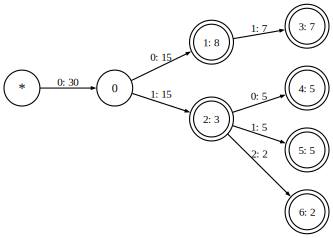

In [3]:
pl.network_visualisation(
    transition_matrix=prefix_tree_acceptor, 
    states=states, 
    alphabet=alphabet, 
    filename="prefix_tree_acceptor", 
    save=False, 
    probabilities=False, 
    graph_format="pdf", 
)

The prefix-tree acceptor is displayed from left to right.

The artificial starting state is represented by `"*"`. Each directed edge represents an observed transition between two states. With `probabilities=False`, the edge labels show the symbol associated with the transition and its observed count.

The first transition leaving the artificial starting state is labelled only by its count.

A double circle indicates that at least one observed sequence terminates at that state. The value shown after the state identifier is the number of sequences terminating there. States at which no sequences terminate are shown with a value of zero.

Because this is a prefix-tree representation, each distinct observed prefix initially has its own state.

## 2. Visualise a learned Deterministic Finite Automaton (DFA) using Graphviz

We can now apply the Alergia algorithm to learn a deterministic finite automaton (DFA) from the observed sequences, as in the previous tutorial. 

In [4]:
learned_dfa, learned_states, tracking = pl.alergia(
    prefix_tree_acceptor,
    states,
    alphabet,
    alpha=0.2,
    method="carrasco",
)

We can compare the number of states in the original prefix-tree acceptor with the number of states remaining after the state-merging process:

In [5]:
print("Number of PTA states:", len(states)) 
print("Number of learned states:", len(learned_states))

Number of PTA states: 8
Number of learned states: 4


The learned DFA can be visualised in the same way as the prefix-tree acceptor.

We will first retain `probabilities=False` so that the node and edge labels display the transition and termination counts associated with the learned automaton.

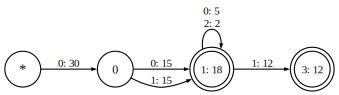

In [6]:
pl.network_visualisation(
    transition_matrix=learned_dfa, 
    states=learned_states, 
    alphabet=alphabet, 
    filename="learned_dfa", 
    save=False, 
    probabilities=False, 
    graph_format="pdf", 
)

Please note that multiple self-loop labels are combined into a single loop. Without this, the self-loops would overlap and be difficult to read.

The learned network is more compact than the original prefix-tree acceptor.

The edge labels continue to show transition counts. Where multiple prefix-tree states have been merged, the counts associated with their transitions are combined in the learned automaton.

The values shown within terminating states represent the number of observed sequences terminating at those states.

## 3. Visualise a learned Probabilistic Deterministic Finite Automaton (PDFA) using Graphviz

The learned automaton can instead be labelled using transition and termination probabilities by setting `probabilities=True`.

The original `transition-count` matrix should still be passed to network_visualisation. The function calculates the corresponding probability transition matrix internally before constructing the graph.

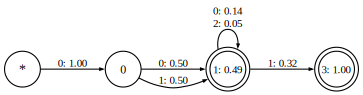

In [7]:
pl.network_visualisation(
    transition_matrix=learned_dfa, 
    states=learned_states, 
    alphabet=alphabet, 
    filename="learned_dfa", 
    save=False, 
    probabilities=True, 
    graph_format="pdf", 
)

The structure of the automaton has not changed, but its labels now display probabilities rather than counts.

For transitions leaving states other than `"*"`, each edge label contains the relevant alphabet symbol followed by its transition probability.

For terminating states, the value displayed after the state identifier is the probability that a sequence terminates at that state. A double circle therefore identifies a state with a positive termination probability.

For each state, the transition probabilities and termination probability together define the possible outcomes from that state. Note that the displayed values are rounded to two decimal places, so they may not appear to sum to exactly one.

## Summary

In this tutorial, we constructed and visualised a prefix-tree acceptor using observed transition counts. We then applied ALERGIA and compared the original tree with the more compact learned automaton.

Finally, we visualised the learned PDFA using transition and termination probabilities and demonstrated how the rendered network can be saved in different file formats.

The next tutorial evaluates a learned PDFA using training and test sequences.